# Experiment 06: Crop Strategy Comparison after Light Augmentation

**Goal:** Continue the step-by-step experiment route after selecting:

1. DenseNet121 baseline
2. HybridChenOrdinalLoss
3. Class-weighted HybridChenOrdinalLoss
4. `light_aug_224` preprocessing

This experiment tests whether changing the input from a single full X-ray image to multiple anatomical regions improves knee OA grading.

Compared crop strategies:

- `single_wide`: full X-ray only
- `center_only`: central joint space only
- `wide_center_2crop`: full X-ray + central joint space
- `wide_center_edges_4crop`: full X-ray + central joint space + left edge + right edge

The model, loss, class weighting, and augmentation are kept consistent so this remains a clean input-representation comparison.

## 1. Imports & Environment Setup

This section contains the fixed imports required for the experiment.

In [64]:
from pathlib import Path
import os
import random
import json
import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, models, datasets

from sklearn.metrics import (
   accuracy_score,
   f1_score,
   confusion_matrix,
   classification_report,
   cohen_kappa_score,
   ConfusionMatrixDisplay
)

from PIL import Image
from tqdm import tqdm

try:
    import cv2
    CV2_AVAILABLE = True
except Exception:
    CV2_AVAILABLE = False

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("OpenCV available:", CV2_AVAILABLE)

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
OpenCV available: True


## 2. Configuration Section

This block makes the experiment reproducible. The selected setting is based on the previous stage: **Class-weighted HybridChenOrdinalLoss + light augmentation at image size 224**.

In [65]:
CONFIG = {
   "EXPERIMENT_NAME": "exp06_crop_strategy_classweighted_hybridchen_lightaug224",
   "IMG_SIZE": 224,
   "BATCH_SIZE": 16,
   "EPOCHS": 30,
   "PATIENCE": 7,
   "LR": 1e-4,
   "WEIGHT_DECAY": 0.0,
   "DROPOUT": 0.3,
   "SEED": 42,
   "MODEL_NAME": "DenseNet121",
   "LOSS": "ClassWeightedHybridChenOrdinalLoss",
   "NUM_CLASSES": 5,
   "NUM_WORKERS": 0,
   "USE_AMP": True,
   "ORDINAL_ALPHA": 0.10,
   "PENALTY_DISTANCE": 2,
   "SQUARE_LOSS": False,
   "NORMALIZE_MATRIX": True,
   "BEST_SELECTION_METRIC": "best_val_qwk",
}

CROP_EXPERIMENTS = [
    {"name": "single_wide", "crop_names": ["wide"]},
    {"name": "center_only", "crop_names": ["center"]},
    {"name": "wide_center_2crop", "crop_names": ["wide", "center"]},
    {"name": "wide_center_edges_4crop", "crop_names": ["wide", "center", "left_edge", "right_edge"]},
]

CROP_RATIOS = {
    "wide":       {"cx": 0.50, "cy": 0.50, "wr": 1.00, "hr": 1.00},
    "center":     {"cx": 0.50, "cy": 0.50, "wr": 0.70, "hr": 0.80},
    "left_edge":  {"cx": 0.30, "cy": 0.50, "wr": 0.55, "hr": 0.80},
    "right_edge": {"cx": 0.70, "cy": 0.50, "wr": 0.55, "hr": 0.80},
}

OUTPUT_ROOT = Path("/kaggle/working") / CONFIG["EXPERIMENT_NAME"]
RESULTS_DIR = OUTPUT_ROOT / "results"
MODELS_DIR = OUTPUT_ROOT / "models"
FIGURES_DIR = OUTPUT_ROOT / "figures"

for p in [RESULTS_DIR, MODELS_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(json.dumps(CONFIG, indent=2))
print("Crop experiments:")
for exp in CROP_EXPERIMENTS:
    print(" -", exp)
print("Output root:", OUTPUT_ROOT)

{
  "EXPERIMENT_NAME": "exp06_crop_strategy_classweighted_hybridchen_lightaug224",
  "IMG_SIZE": 224,
  "BATCH_SIZE": 16,
  "EPOCHS": 30,
  "PATIENCE": 7,
  "LR": 0.0001,
  "WEIGHT_DECAY": 0.0,
  "DROPOUT": 0.3,
  "SEED": 42,
  "MODEL_NAME": "DenseNet121",
  "LOSS": "ClassWeightedHybridChenOrdinalLoss",
  "NUM_CLASSES": 5,
  "NUM_WORKERS": 0,
  "USE_AMP": true,
  "ORDINAL_ALPHA": 0.1,
  "PENALTY_DISTANCE": 2,
  "SQUARE_LOSS": false,
  "NORMALIZE_MATRIX": true,
  "BEST_SELECTION_METRIC": "best_val_qwk"
}
Crop experiments:
 - {'name': 'single_wide', 'crop_names': ['wide']}
 - {'name': 'center_only', 'crop_names': ['center']}
 - {'name': 'wide_center_2crop', 'crop_names': ['wide', 'center']}
 - {'name': 'wide_center_edges_4crop', 'crop_names': ['wide', 'center', 'left_edge', 'right_edge']}
Output root: /kaggle/working/exp06_crop_strategy_classweighted_hybridchen_lightaug224


## 3. Dataset Paths

The dataset is expected to have `train`, `val`, and `test` folders under the Kaggle input path.

In [66]:
DATA_ROOT = Path("/kaggle/input/datasets/joylyuyue/split-data")

TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not d.exists():
        raise FileNotFoundError(f"Missing folder: {d}")

print("Dataset paths are valid.")

DATA_ROOT: /kaggle/input/datasets/joylyuyue/split-data
TRAIN_DIR: /kaggle/input/datasets/joylyuyue/split-data/train
VAL_DIR: /kaggle/input/datasets/joylyuyue/split-data/val
TEST_DIR: /kaggle/input/datasets/joylyuyue/split-data/test
Dataset paths are valid.


## 4. Seed Fixing

Seed fixing improves reproducibility across runs.

In [67]:
def set_seed(seed=42):
   random.seed(seed)
   np.random.seed(seed)
   torch.manual_seed(seed)
   torch.cuda.manual_seed_all(seed)
   torch.backends.cudnn.benchmark = True

set_seed(CONFIG["SEED"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 5. Data Preprocessing

This experiment uses the selected `light_aug_224` setting from the previous stage.

Training preprocessing:
- Resize/crop to 224 after crop extraction
- Random horizontal flip
- Small affine transformation: rotation 5°, translation 2%, scale 0.97–1.03
- Normalization using ImageNet-style mean/std for grayscale X-rays copied into 3 channels

Validation/test preprocessing:
- Resize only
- Tensor conversion
- Normalization

CLAHE is included for visualization only, not for training in this experiment.

In [68]:
IMG_SIZE = CONFIG["IMG_SIZE"]
NORMALIZE_MEAN = [0.485, 0.485, 0.485]
NORMALIZE_STD = [0.229, 0.229, 0.229]

train_pre_crop_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(
        degrees=5,
        translate=(0.02, 0.02),
        scale=(0.97, 1.03),
        fill=0,
    ),
])

post_crop_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD),
])

raw_preview_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD),
])

print("Training augmentation:")
print(train_pre_crop_aug)
print("Post-crop transform:")
print(post_crop_transform)

Training augmentation:
Compose(
    RandomHorizontalFlip(p=0.5)
    RandomAffine(degrees=[-5.0, 5.0], translate=(0.02, 0.02), scale=(0.97, 1.03))
)
Post-crop transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.485, 0.485], std=[0.229, 0.229, 0.229])
)


In [69]:
def make_crop_box(width, height, cx, cy, wr, hr):
    box_w = int(width * wr)
    box_h = int(height * hr)
    center_x = int(width * cx)
    center_y = int(height * cy)
    left = max(0, center_x - box_w // 2)
    top = max(0, center_y - box_h // 2)
    right = min(width, left + box_w)
    bottom = min(height, top + box_h)
    left = max(0, right - box_w)
    top = max(0, bottom - box_h)
    return (left, top, right, bottom)

class MultiRegionCropTransform:
    def __init__(self, crop_names, train=False):
        self.crop_names = crop_names
        self.train = train

    def __call__(self, img):
        img = img.convert("RGB")
        if self.train:
            img = train_pre_crop_aug(img)
        w, h = img.size
        crop_tensors = []
        for name in self.crop_names:
            r = CROP_RATIOS[name]
            if name == "wide":
                crop_img = img
            else:
                box = make_crop_box(w, h, r["cx"], r["cy"], r["wr"], r["hr"])
                crop_img = img.crop(box)
            crop_tensors.append(post_crop_transform(crop_img))
        return torch.stack(crop_tensors, dim=0)

def denormalize_tensor(img_tensor):
    img = img_tensor.detach().cpu().clone()
    mean = torch.tensor(NORMALIZE_MEAN).view(3, 1, 1)
    std = torch.tensor(NORMALIZE_STD).view(3, 1, 1)
    img = img * std + mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

def apply_clahe_for_preview(pil_img):
    gray = np.array(pil_img.convert("L"))
    if CV2_AVAILABLE:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        out = clahe.apply(gray)
    else:
        hist, bins = np.histogram(gray.flatten(), 256, [0, 256])
        cdf = hist.cumsum()
        cdf = 255 * cdf / cdf[-1]
        out = np.interp(gray.flatten(), bins[:-1], cdf).reshape(gray.shape).astype(np.uint8)
    return Image.fromarray(out).convert("RGB")

## 6. Dataset & Dataloader

This section prints train/validation/test sizes and class distribution. For each crop strategy, dataloaders are rebuilt with the corresponding crop transform.

Class to index: {'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}
Train size: 1024
Val size: 146
Test size: 294


,split,class_idx,class_name,count,percentage
0,train,0,0Normal,316,0.308594
1,train,1,1Doubtful,308,0.300781
2,train,2,2Mild,134,0.130859
3,train,3,3Moderate,122,0.119141
4,train,4,4Severe,144,0.140625
5,val,0,0Normal,45,0.308219
6,val,1,1Doubtful,44,0.301370
7,val,2,2Mild,19,0.130137
8,val,3,3Moderate,18,0.123288
9,val,4,4Severe,20,0.136986


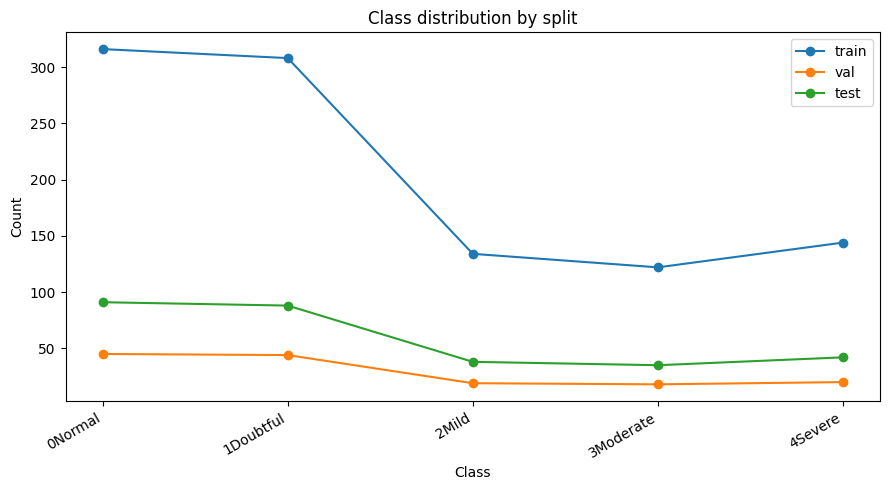

In [70]:
raw_train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=None)
raw_val_dataset = datasets.ImageFolder(VAL_DIR, transform=None)
raw_test_dataset = datasets.ImageFolder(TEST_DIR, transform=None)

class_names = raw_train_dataset.classes
class_to_idx = raw_train_dataset.class_to_idx
num_classes = len(class_names)

print("Class to index:", class_to_idx)
print("Train size:", len(raw_train_dataset))
print("Val size:", len(raw_val_dataset))
print("Test size:", len(raw_test_dataset))
assert num_classes == CONFIG["NUM_CLASSES"], f"Expected {CONFIG['NUM_CLASSES']} classes, got {num_classes}"

def get_targets(dataset):
    return np.array([label for _, label in dataset.samples])

def split_distribution_df(dataset, split_name):
    targets = get_targets(dataset)
    counts = np.bincount(targets, minlength=num_classes)
    return pd.DataFrame({
        "split": split_name,
        "class_idx": list(range(num_classes)),
        "class_name": class_names,
        "count": counts,
        "percentage": counts / counts.sum(),
    })

dist_df = pd.concat([
    split_distribution_df(raw_train_dataset, "train"),
    split_distribution_df(raw_val_dataset, "val"),
    split_distribution_df(raw_test_dataset, "test"),
], ignore_index=True)

display(dist_df)

plt.figure(figsize=(9, 5))
for split_name in ["train", "val", "test"]:
    temp = dist_df[dist_df["split"] == split_name]
    plt.plot(temp["class_name"], temp["count"], marker="o", label=split_name)
plt.title("Class distribution by split")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
def build_dataloaders_for_crop_mode(crop_names, batch_size=None):
    if batch_size is None:
        batch_size = CONFIG["BATCH_SIZE"]

    train_dataset = datasets.ImageFolder(
        TRAIN_DIR,
        transform=MultiRegionCropTransform(crop_names=crop_names, train=True)
    )
    val_dataset = datasets.ImageFolder(
        VAL_DIR,
        transform=MultiRegionCropTransform(crop_names=crop_names, train=False)
    )
    test_dataset = datasets.ImageFolder(
        TEST_DIR,
        transform=MultiRegionCropTransform(crop_names=crop_names, train=False)
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=CONFIG["NUM_WORKERS"], pin_memory=torch.cuda.is_available())
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                            num_workers=CONFIG["NUM_WORKERS"], pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                             num_workers=CONFIG["NUM_WORKERS"], pin_memory=torch.cuda.is_available())
    return train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset

_, _, _, preview_dataset, _, _ = build_dataloaders_for_crop_mode(["wide", "center", "left_edge", "right_edge"])
preview_crops, preview_label = preview_dataset[0]
print("Preview crop tensor shape:", preview_crops.shape)
print("Preview label:", preview_label, class_names[preview_label])

Preview crop tensor shape: torch.Size([4, 3, 224, 224])
Preview label: 0 0Normal


## 7. Visualization

This section displays original image, transformed image, CLAHE preview, and 4-crop example.

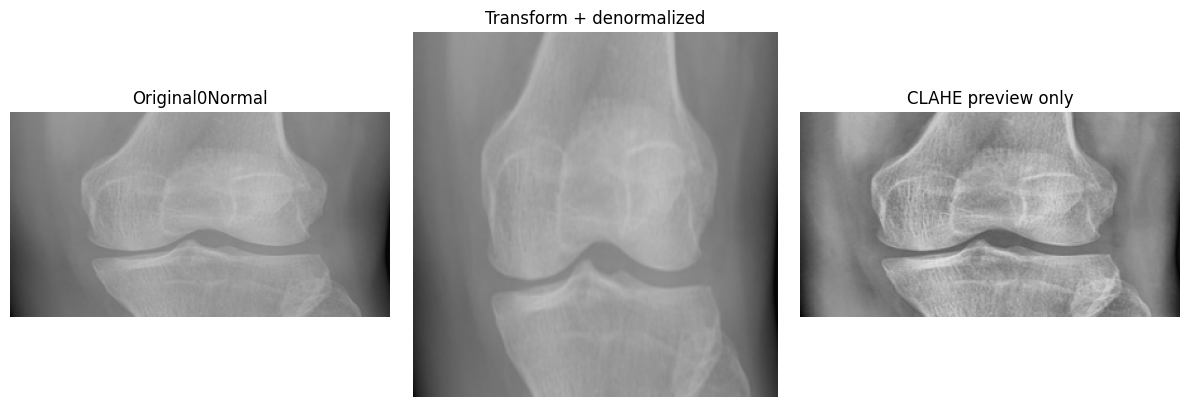

In [72]:
def show_preprocessing_examples(sample_idx=0):
    img_path, label = raw_train_dataset.samples[sample_idx]
    original = Image.open(img_path).convert("RGB")
    transformed = raw_preview_transform(original)
    transformed_np = denormalize_tensor(transformed)
    clahe_img = apply_clahe_for_preview(original)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap="gray")
    plt.title(f"Original{class_names[label]}")
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.imshow(transformed_np)
    plt.title("Transform + denormalized")
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.imshow(clahe_img, cmap="gray")
    plt.title("CLAHE preview only")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

show_preprocessing_examples(sample_idx=0)

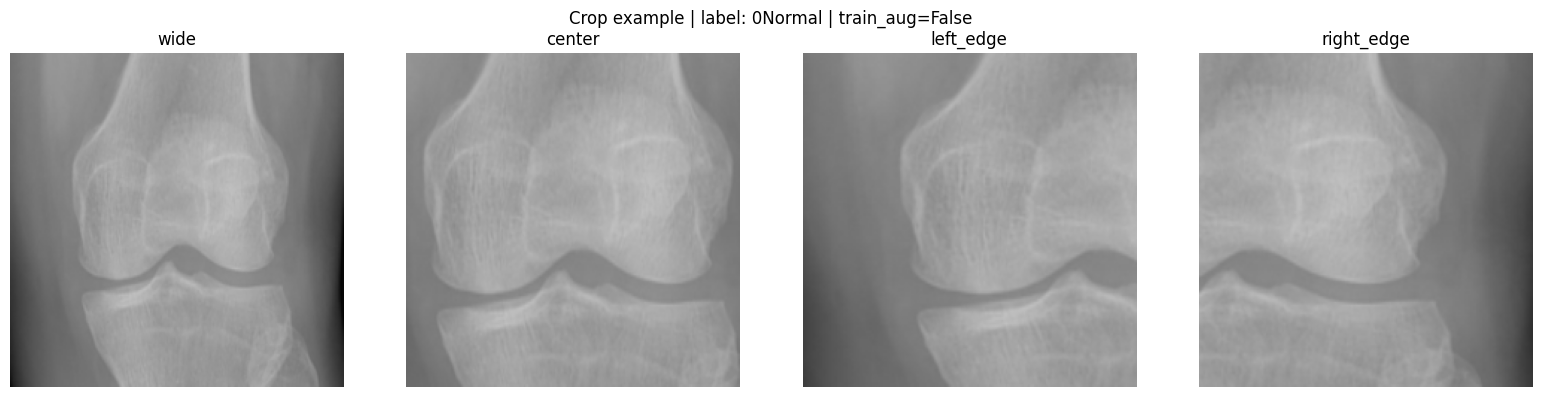

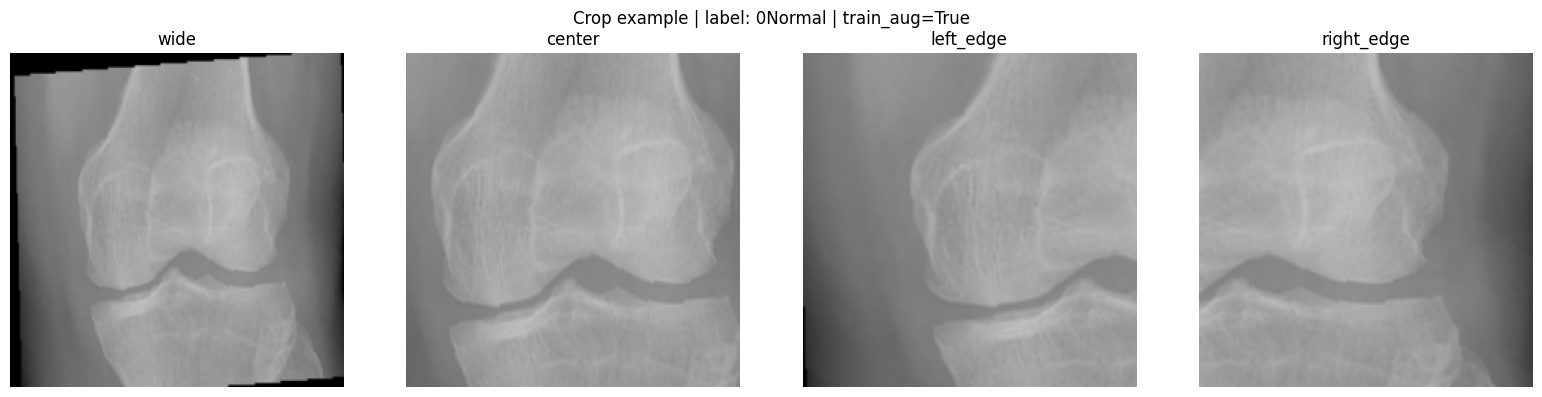

In [73]:
def show_crop_example(sample_idx=0, crop_names=["wide", "center", "left_edge", "right_edge"], train_aug=False):
    img_path, label = raw_train_dataset.samples[sample_idx]
    img = Image.open(img_path).convert("RGB")
    transform = MultiRegionCropTransform(crop_names=crop_names, train=train_aug)
    crops = transform(img)
    plt.figure(figsize=(4 * len(crop_names), 4))
    for i, name in enumerate(crop_names):
        plt.subplot(1, len(crop_names), i + 1)
        plt.imshow(denormalize_tensor(crops[i]))
        plt.title(name)
        plt.axis("off")
    plt.suptitle(f"Crop example | label: {class_names[label]} | train_aug={train_aug}")
    plt.tight_layout()
    plt.show()

show_crop_example(0, ["wide", "center", "left_edge", "right_edge"], train_aug=False)
show_crop_example(0, ["wide", "center", "left_edge", "right_edge"], train_aug=True)

## 8. Model Definition

The model uses a shared DenseNet121 backbone for all crops. Crop features are mean-pooled before classification.

In [74]:
class MultiCropDenseNet121(nn.Module):
    def __init__(self, num_classes=5, dropout=0.3, pretrained=True):
        super().__init__()
        weights = models.DenseNet121_Weights.DEFAULT if pretrained else None
        base = models.densenet121(weights=weights)
        self.features = base.features
        in_features = base.classifier.in_features
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, crops):
        if crops.dim() == 4:
            crops = crops.unsqueeze(1)
        b, n, c, h, w = crops.shape
        x = crops.view(b * n, c, h, w)
        feat_maps = self.features(x)
        feat_maps = F.relu(feat_maps, inplace=True)
        pooled = F.adaptive_avg_pool2d(feat_maps, (1, 1)).view(b, n, -1)
        fused = pooled.mean(dim=1)
        logits = self.classifier(self.dropout(fused))
        return logits

def build_model():
    return MultiCropDenseNet121(num_classes=CONFIG["NUM_CLASSES"],
                                dropout=CONFIG["DROPOUT"],
                                pretrained=True).to(device)

model_check = build_model()
print(model_check.__class__.__name__)
print("Classifier:", model_check.classifier)
del model_check
if torch.cuda.is_available():
    torch.cuda.empty_cache()

MultiCropDenseNet121
Classifier: Linear(in_features=1024, out_features=5, bias=True)


## 9. Loss Function

This experiment uses **Class-weighted HybridChenOrdinalLoss**.

```text
loss = class_weighted_cross_entropy + alpha * Chen-style ordinal penalty
```

This keeps normal classification learning while penalizing severe grading errors.

In [75]:
train_targets = get_targets(raw_train_dataset)
train_class_counts = np.bincount(train_targets, minlength=num_classes)
class_weights_np = train_class_counts.sum() / (num_classes * train_class_counts)
class_weights_np = class_weights_np / class_weights_np.mean()
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

class_weight_df = pd.DataFrame({
    "class_idx": range(num_classes),
    "class_name": class_names,
    "train_count": train_class_counts,
    "class_weight": class_weights_np,
})
display(class_weight_df)

class ClassWeightedHybridChenOrdinalLoss(nn.Module):
    def __init__(self, num_classes=5, class_weights=None, alpha=0.1,
                 penalty_distance=2, square_loss=False, normalize=True):
        super().__init__()
        self.num_classes = num_classes
        self.alpha = alpha
        self.penalty_distance = penalty_distance
        self.square_loss = square_loss
        self.normalize = normalize
        self.ce_loss = nn.CrossEntropyLoss(weight=class_weights)
        penalty_matrix = self._create_penalty_matrix(num_classes, penalty_distance, normalize)
        self.register_buffer("penalty_matrix", penalty_matrix)

    def _create_penalty_matrix(self, num_classes, penalty_distance, normalize):
        class_indices = torch.arange(num_classes, dtype=torch.float32)
        distance_matrix = torch.abs(class_indices.unsqueeze(0) - class_indices.unsqueeze(1))
        penalty_matrix = distance_matrix * penalty_distance + 1.0
        penalty_matrix[distance_matrix == 0] = 0.0
        if normalize and penalty_matrix.max() > 0:
            penalty_matrix = penalty_matrix / penalty_matrix.max()
        return penalty_matrix

    def forward(self, logits, targets, return_parts=False):
        ce = self.ce_loss(logits, targets)
        probabilities = F.softmax(logits, dim=1)
        target_penalties = self.penalty_matrix.to(logits.device)[targets.long()]
        penalty_per_sample = torch.sum(probabilities * target_penalties, dim=1)
        if self.square_loss:
            penalty_per_sample = penalty_per_sample ** 2
        ordinal_penalty = torch.mean(penalty_per_sample)
        total_loss = ce + self.alpha * ordinal_penalty
        if return_parts:
            return total_loss, ce, ordinal_penalty, self.alpha * ordinal_penalty
        return total_loss

criterion_check = ClassWeightedHybridChenOrdinalLoss(
    num_classes=num_classes,
    class_weights=class_weights,
    alpha=CONFIG["ORDINAL_ALPHA"],
    penalty_distance=CONFIG["PENALTY_DISTANCE"],
    square_loss=CONFIG["SQUARE_LOSS"],
    normalize=CONFIG["NORMALIZE_MATRIX"],
).to(device)

print("Loss:", CONFIG["LOSS"])
print("Formula: weighted CE +", CONFIG["ORDINAL_ALPHA"], "* Chen ordinal penalty")
print("Penalty matrix:")
print(criterion_check.penalty_matrix.detach().cpu().numpy())

,class_idx,class_name,train_count,class_weight
0,0,0Normal,316,0.545328
1,1,1Doubtful,308,0.559493
2,2,2Mild,134,1.285998
3,3,3Moderate,122,1.412489
4,4,4Severe,144,1.196692


Loss: ClassWeightedHybridChenOrdinalLoss
Formula: weighted CE + 0.1 * Chen ordinal penalty
Penalty matrix:
[[0.         0.33333334 0.5555556  0.7777778  1.        ]
 [0.33333334 0.         0.33333334 0.5555556  0.7777778 ]
 [0.5555556  0.33333334 0.         0.33333334 0.5555556 ]
 [0.7777778  0.5555556  0.33333334 0.         0.33333334]
 [1.         0.7777778  0.5555556  0.33333334 0.        ]]


## 10. Optimizer & Scheduler

Each crop strategy gets a fresh model, optimizer, and scheduler.

In [76]:
def build_criterion():
    return ClassWeightedHybridChenOrdinalLoss(
        num_classes=num_classes,
        class_weights=class_weights,
        alpha=CONFIG["ORDINAL_ALPHA"],
        penalty_distance=CONFIG["PENALTY_DISTANCE"],
        square_loss=CONFIG["SQUARE_LOSS"],
        normalize=CONFIG["NORMALIZE_MATRIX"],
    ).to(device)

def build_optimizer_scheduler(model):
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["LR"], weight_decay=CONFIG["WEIGHT_DECAY"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["EPOCHS"])
    return optimizer, scheduler

print("Optimizer: AdamW")
print("Scheduler: CosineAnnealingLR")

Optimizer: AdamW
Scheduler: CosineAnnealingLR


## 11. Training Loop

The loop records train loss, validation loss, validation QWK, validation MAE, and validation distant errors. The best checkpoint is selected by validation QWK.

In [77]:
def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true).astype(int)
    y_pred = np.array(y_pred).astype(int)
    diff = np.abs(y_true - y_pred)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "qwk": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "mae": float(np.mean(diff)),
        "total_errors": int(np.sum(diff > 0)),
        "adjacent_errors": int(np.sum(diff == 1)),
        "distant_errors": int(np.sum(diff >= 2)),
    }

def train_one_epoch(model, loader, criterion, optimizer, scaler=None):
    model.train()
    running_loss = 0.0
    running_ce = 0.0
    running_ord = 0.0
    y_true, y_pred = [], []
    use_amp = CONFIG["USE_AMP"] and torch.cuda.is_available()

    for crops, labels in tqdm(loader, desc="train", leave=False):
        crops = crops.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=use_amp):
            logits = model(crops)
            loss, ce_loss, ordinal_loss, _ = criterion(logits, labels, return_parts=True)
        if scaler is not None and use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        bs = labels.size(0)
        running_loss += loss.item() * bs
        running_ce += ce_loss.item() * bs
        running_ord += ordinal_loss.item() * bs
        preds = logits.detach().argmax(dim=1)
        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())

    metrics = compute_metrics(y_true, y_pred)
    metrics["loss"] = running_loss / len(loader.dataset)
    metrics["ce_loss"] = running_ce / len(loader.dataset)
    metrics["ordinal_loss"] = running_ord / len(loader.dataset)
    return metrics

@torch.no_grad()
def evaluate(model, loader, criterion, desc="eval"):
    model.eval()
    running_loss = 0.0
    y_true, y_pred = [], []
    for crops, labels in tqdm(loader, desc=desc, leave=False):
        crops = crops.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(crops)
        loss = criterion(logits, labels)
        bs = labels.size(0)
        running_loss += loss.item() * bs
        preds = logits.argmax(dim=1)
        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())
    metrics = compute_metrics(y_true, y_pred)
    metrics["loss"] = running_loss / len(loader.dataset)
    return metrics, y_true, y_pred

In [78]:
def run_one_crop_experiment(exp_cfg):
    name = exp_cfg["name"]
    crop_names = exp_cfg["crop_names"]
    print("=" * 90)
    print(f"Running crop experiment: {name}")
    print("Crops:", crop_names)
    print("=" * 90)
    set_seed(CONFIG["SEED"])

    train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = build_dataloaders_for_crop_mode(
        crop_names=crop_names,
        batch_size=CONFIG["BATCH_SIZE"],
    )

    model = build_model()
    criterion = build_criterion()
    optimizer, scheduler = build_optimizer_scheduler(model)
    scaler = torch.amp.GradScaler("cuda", enabled=(CONFIG["USE_AMP"] and torch.cuda.is_available()))

    best_val_qwk = -999
    best_epoch = -1
    best_path = MODELS_DIR / f"{CONFIG['EXPERIMENT_NAME']}_{name}_best.pth"
    patience_counter = 0
    history = []

    for epoch in range(1, CONFIG["EPOCHS"] + 1):
        print(f"Epoch {epoch}/{CONFIG['EPOCHS']} | {name}")
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        val_metrics, _, _ = evaluate(model, val_loader, criterion, desc="val")
        scheduler.step()
        row = {"epoch": epoch, "crop_experiment": name}
        row.update({f"train_{k}": v for k, v in train_metrics.items()})
        row.update({f"val_{k}": v for k, v in val_metrics.items()})
        history.append(row)
        print(
            f"train_loss={train_metrics['loss']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
            f"val_qwk={val_metrics['qwk']:.4f} | "
            f"val_mae={val_metrics['mae']:.4f} | "
            f"val_distant={val_metrics['distant_errors']}"
        )
        if val_metrics["qwk"] > best_val_qwk:
            best_val_qwk = val_metrics["qwk"]
            best_epoch = epoch
            patience_counter = 0
            torch.save({
                "model_state_dict": model.state_dict(),
                "config": CONFIG,
                "crop_experiment": exp_cfg,
                "class_names": class_names,
                "class_weights": class_weights.detach().cpu().numpy().tolist(),
                "best_val_qwk": best_val_qwk,
                "best_epoch": best_epoch,
            }, best_path)
            print(f"New best val QWK: {best_val_qwk:.4f}")
        else:
            patience_counter += 1
            print(f"No improvement: {patience_counter}/{CONFIG['PATIENCE']}")
        if patience_counter >= CONFIG["PATIENCE"]:
            print("Early stopping triggered.")
            break

    history_df = pd.DataFrame(history)
    history_df.to_csv(RESULTS_DIR / f"history_{name}.csv", index=False)
    checkpoint = torch.load(best_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    test_metrics, test_true, test_pred = evaluate(model, test_loader, criterion, desc="test")

    print(f"Test results for {name}:")
    for k, v in test_metrics.items():
        print(f"{k}: {v}")

    result = {
        "crop_experiment": name,
        "crop_names": crop_names,
        "num_crops": len(crop_names),
        "best_epoch": best_epoch,
        "best_val_qwk": best_val_qwk, **{f"test_{k}": v for k, v in test_metrics.items()},
        "model_path": str(best_path),
    }
    with open(RESULTS_DIR / f"metrics_{name}.json", "w") as f:
        json.dump(result, f, indent=2)
    report = classification_report(test_true, test_pred, target_names=class_names, output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(RESULTS_DIR / f"classification_report_{name}.csv")
    cm_one = confusion_matrix(test_true, test_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_one, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45)
    plt.title(f"Confusion Matrix: {name}")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / f"confusion_matrix_{name}.png", dpi=200, bbox_inches="tight")
    plt.close(fig)
    del model, optimizer, scheduler, scaler
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result, history_df, test_true, test_pred

## 12. Validation Section

Validation is performed after every epoch using accuracy, macro F1, QWK, MAE, and distant errors. The best checkpoint for each crop strategy is selected by validation QWK.

In [80]:
all_results = []
all_histories = {}
all_test_outputs = {}
start_time = time.time()

for exp_cfg in CROP_EXPERIMENTS:
    result, history_df, test_true, test_pred = run_one_crop_experiment(exp_cfg)
    all_results.append(result)
    all_histories[exp_cfg["name"]] = history_df
    all_test_outputs[exp_cfg["name"]] = {"y_true": test_true, "y_pred": test_pred}

elapsed = time.time() - start_time
print(f"Total running time: {elapsed / 60:.2f} minutes")

Running crop experiment: single_wide
Crops: ['wide']
Epoch 1/30 | single_wide


train_loss=1.3555 | val_loss=0.9139 | val_acc=0.6370 | val_macro_f1=0.6175 | val_qwk=0.8371 | val_mae=0.4658 | val_distant=12
New best val QWK: 0.8371
Epoch 2/30 | single_wide


train_loss=0.8379 | val_loss=0.6919 | val_acc=0.7397 | val_macro_f1=0.7199 | val_qwk=0.8645 | val_mae=0.3425 | val_distant=9
New best val QWK: 0.8645
Epoch 3/30 | single_wide


train_loss=0.6863 | val_loss=0.6925 | val_acc=0.7397 | val_macro_f1=0.7030 | val_qwk=0.8599 | val_mae=0.3562 | val_distant=11
No improvement: 1/7
Epoch 4/30 | single_wide


train_loss=0.5651 | val_loss=0.5474 | val_acc=0.8356 | val_macro_f1=0.8167 | val_qwk=0.9101 | val_mae=0.2192 | val_distant=6
New best val QWK: 0.9101
Epoch 5/30 | single_wide


...

train_loss=0.2205 | val_loss=0.3947 | val_acc=0.8493 | val_macro_f1=0.8514 | val_qwk=0.9054 | val_mae=0.2123 | val_distant=6
No improvement: 4/7
Epoch 13/30 | wide_center_edges_4crop


train_loss=0.1550 | val_loss=0.3742 | val_acc=0.8562 | val_macro_f1=0.8635 | val_qwk=0.9165 | val_mae=0.1918 | val_distant=4
No improvement: 5/7
Epoch 14/30 | wide_center_edges_4crop


train_loss=0.1201 | val_loss=0.4529 | val_acc=0.8356 | val_macro_f1=0.8380 | val_qwk=0.9235 | val_mae=0.2055 | val_distant=5
No improvement: 6/7
Epoch 15/30 | wide_center_edges_4crop


train_loss=0.1052 | val_loss=0.3743 | val_acc=0.8699 | val_macro_f1=0.8776 | val_qwk=0.9282 | val_mae=0.1712 | val_distant=4
No improvement: 7/7
Early stopping triggered.


Test results for wide_center_edges_4crop:
accuracy: 0.7721088435374149
macro_f1: 0.7581414820571646
weighted_f1: 0.7716247641437229
qwk: 0.8879485748239913
mae: 0.2891156462585034
total_errors: 67
adjacent_errors: 52
distant_errors: 15
loss: 0.5648844082947491
Total running time: 22.42 minutes


## 13. Test Evaluation

This section compares the test performance of all crop strategies.

In [81]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(by="best_val_qwk", ascending=False)

display_cols = [
    "crop_experiment", "num_crops", "best_epoch", "best_val_qwk",
    "test_accuracy", "test_macro_f1", "test_weighted_f1", "test_qwk",
    "test_mae", "test_total_errors", "test_adjacent_errors", "test_distant_errors",
]

display(results_df[display_cols])
results_df.to_csv(RESULTS_DIR / "crop_comparison_results.csv", index=False)

best_row = results_df.iloc[0]
BEST_CROP_EXPERIMENT = best_row["crop_experiment"]
print("Selected best crop experiment by validation QWK:", BEST_CROP_EXPERIMENT)
print(best_row[display_cols].to_string())

,crop_experiment,num_crops,best_epoch,best_val_qwk,test_accuracy,test_macro_f1,test_weighted_f1,test_qwk,test_mae,test_total_errors,test_adjacent_errors,test_distant_errors
0,single_wide,1,18,0.959849,0.775510,0.769263,0.776651,0.879516,0.292517,66,51,15
2,wide_center_2crop,2,13,0.941876,0.772109,0.764768,0.773251,0.871816,0.302721,67,51,16
3,wide_center_edges_4crop,4,8,0.940667,0.772109,0.758141,0.771625,0.887949,0.289116,67,52,15
1,center_only,1,8,0.917952,0.789116,0.779467,0.789388,0.880877,0.278912,62,48,14


Selected best crop experiment by validation QWK: single_wide
crop_experiment         single_wide
num_crops                         1
best_epoch                       18
best_val_qwk               0.959849
test_accuracy               0.77551
test_macro_f1              0.769263
test_weighted_f1           0.776651
test_qwk                   0.879516
test_mae                   0.292517
test_total_errors                66
test_adjacent_errors             51
test_distant_errors              15


## 13.1 Per-class Recall and F1

Class-wise recall and F1 are important because the dataset is imbalanced and some OA grades are harder to classify.

In [82]:
classwise_rows = []
for result in all_results:
    name = result["crop_experiment"]
    y_true = all_test_outputs[name]["y_true"]
    y_pred = all_test_outputs[name]["y_pred"]
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    for cls in class_names:
        classwise_rows.append({
            "crop_experiment": name,
            "class_name": cls,
            "precision": report[cls]["precision"],
            "recall": report[cls]["recall"],
            "f1_score": report[cls]["f1-score"],
            "support": report[cls]["support"],
        })
classwise_df = pd.DataFrame(classwise_rows)
display(classwise_df)
classwise_df.to_csv(RESULTS_DIR / "classwise_recall_f1_comparison.csv", index=False)

,crop_experiment,class_name,precision,recall,f1_score,support
0,single_wide,0Normal,0.838710,0.857143,0.847826,91.0
1,single_wide,1Doubtful,0.772152,0.693182,0.730539,88.0
2,single_wide,2Mild,0.583333,0.736842,0.651163,38.0
3,single_wide,3Moderate,0.789474,0.857143,0.821918,35.0
4,single_wide,4Severe,0.861111,0.738095,0.794872,42.0
5,center_only,0Normal,0.880952,0.813187,0.845714,91.0
6,center_only,1Doubtful,0.724490,0.806818,0.763441,88.0
7,center_only,2Mild,0.600000,0.552632,0.575342,38.0
8,center_only,3Moderate,0.794872,0.885714,0.837838,35.0
9,center_only,4Severe,0.921053,0.833333,0.875000,42.0


## 14. Confusion Matrix

The confusion matrix is shown for the selected best crop strategy.

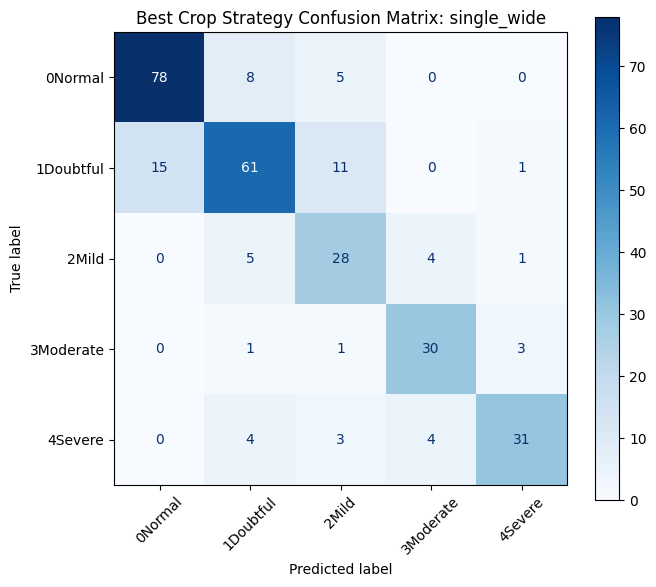

In [83]:
best_true = all_test_outputs[BEST_CROP_EXPERIMENT]["y_true"]
best_pred = all_test_outputs[BEST_CROP_EXPERIMENT]["y_pred"]
cm = confusion_matrix(best_true, best_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45)
plt.title(f"Best Crop Strategy Confusion Matrix: {BEST_CROP_EXPERIMENT}")
plt.tight_layout()
plt.show()
fig.savefig(FIGURES_DIR / "confusion_matrix_best_crop.png", dpi=200, bbox_inches="tight")

## 15. Error Analysis

Adjacent and distant errors are especially important for ordinal OA grading.

,crop_experiment,correct,adjacent_errors,distant_errors,total_errors,mean_absolute_error
1,center_only,232,48,14,62,0.278912
0,single_wide,228,51,15,66,0.292517
3,wide_center_edges_4crop,227,52,15,67,0.289116
2,wide_center_2crop,227,51,16,67,0.302721


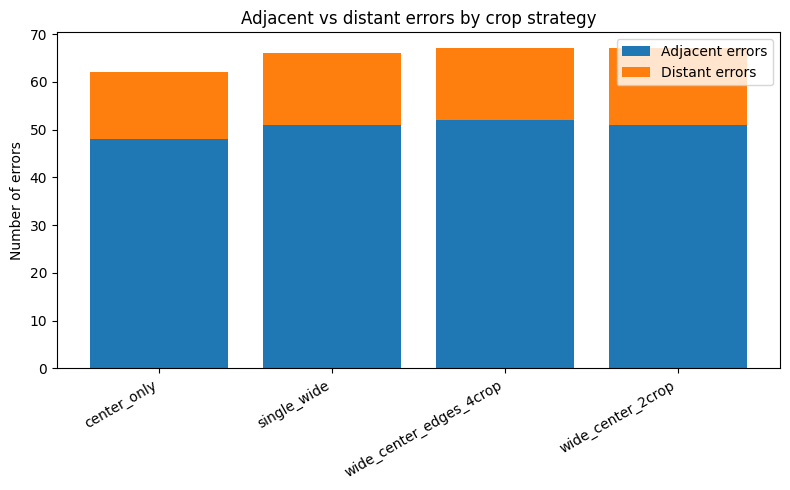

In [84]:
error_rows = []
for result in all_results:
    name = result["crop_experiment"]
    y_true = np.array(all_test_outputs[name]["y_true"])
    y_pred = np.array(all_test_outputs[name]["y_pred"])
    diff = np.abs(y_true - y_pred)
    error_rows.append({
        "crop_experiment": name,
        "correct": int(np.sum(diff == 0)),
        "adjacent_errors": int(np.sum(diff == 1)),
        "distant_errors": int(np.sum(diff >= 2)),
        "total_errors": int(np.sum(diff > 0)),
        "mean_absolute_error": float(np.mean(diff)),
    })
error_df = pd.DataFrame(error_rows).sort_values(by="distant_errors")
display(error_df)
error_df.to_csv(RESULTS_DIR / "error_analysis_comparison.csv", index=False)

plt.figure(figsize=(8, 5))
plt.bar(error_df["crop_experiment"], error_df["adjacent_errors"], label="Adjacent errors")
plt.bar(error_df["crop_experiment"], error_df["distant_errors"], bottom=error_df["adjacent_errors"], label="Distant errors")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Number of errors")
plt.title("Adjacent vs distant errors by crop strategy")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "error_analysis_crop_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

wrong samples: 66 / 294


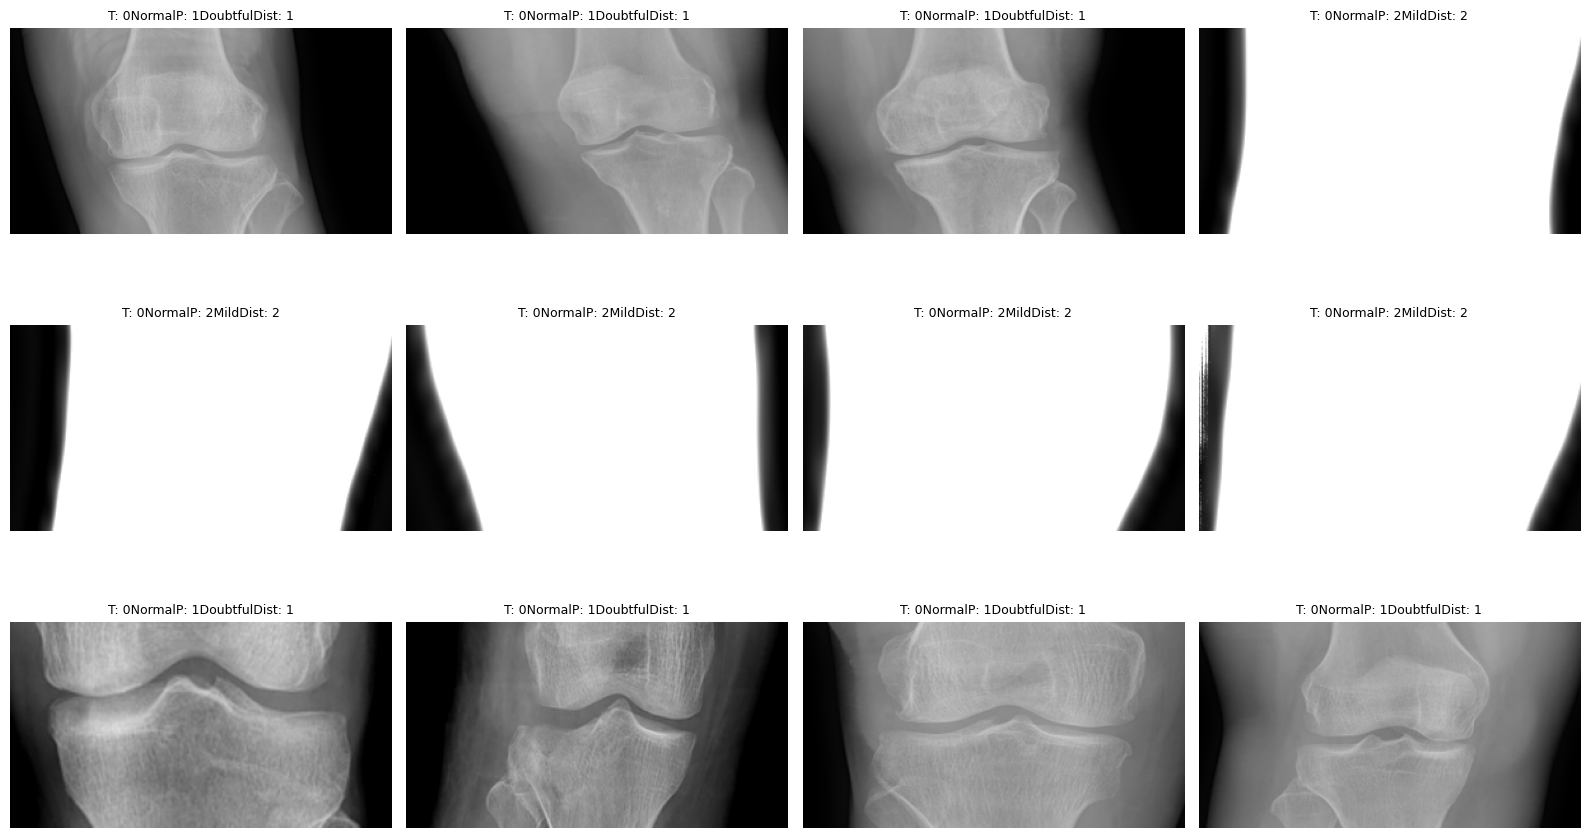

In [86]:
def show_misclassified_raw_images(y_true, y_pred, max_images=12):
    wrong_indices = [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if int(t) != int(p)]
    print(f"wrong samples: {len(wrong_indices)} / {len(y_true)}")
    show_indices = wrong_indices[:max_images]
    cols = 4
    rows = math.ceil(len(show_indices) / cols) if show_indices else 1
    plt.figure(figsize=(cols * 4, rows * 3.2))
    for plot_i, idx in enumerate(show_indices, start=1):
        img_path, _ = raw_test_dataset.samples[idx]
        true_label = int(y_true[idx])
        pred_label = int(y_pred[idx])
        dist = abs(true_label - pred_label)
        img = Image.open(img_path).convert("L")
        plt.subplot(rows, cols, plot_i)
        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
        plt.axis("off")
        plt.title(f"T: {class_names[true_label]}P: {class_names[pred_label]}Dist: {dist}", fontsize=9)
    plt.tight_layout()
    plt.show()

show_misclassified_raw_images(best_true, best_pred, max_images=12)

## 16. Grad-CAM

Grad-CAM is shown for one correct and one wrong prediction from the selected best crop strategy. For multi-crop models, this Grad-CAM visualizes the first crop in the selected crop list.

Correct example index: 0
Wrong example index: 3
Grad-CAM crop displayed: wide


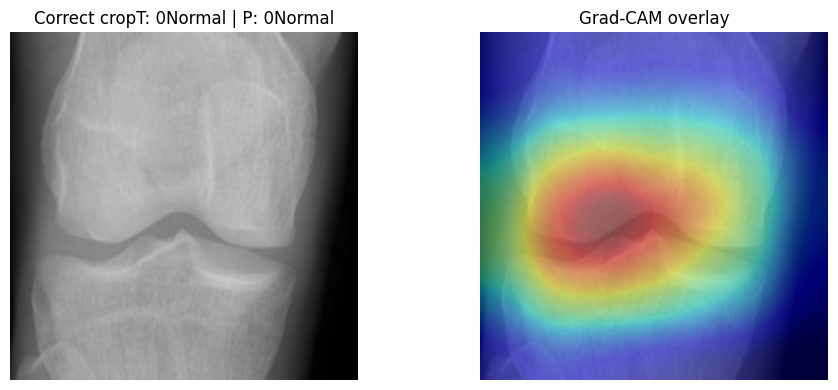

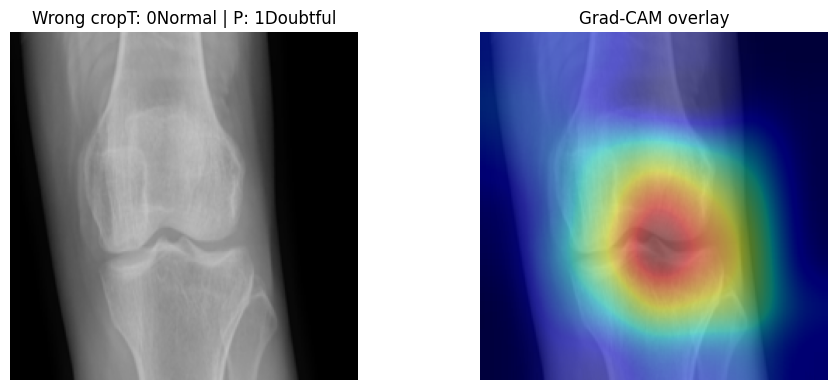

In [89]:
class GradCAMHelper:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.fwd_handle = target_layer.register_forward_hook(self._forward_hook)
        self.bwd_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

    def generate(self, crops, class_idx=None, crop_index=0):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(crops)
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())
        score = logits[:, class_idx].sum()
        score.backward()
        act = self.activations[crop_index]
        grad = self.gradients[crop_index]
        weights = grad.mean(dim=(1, 2), keepdim=True)
        cam = (weights * act).sum(dim=0)
        cam = F.relu(cam)
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam.cpu().numpy(), class_idx

def overlay_cam_on_image(img_np, cam):
    cam_img = Image.fromarray((cam * 255).astype(np.uint8)).resize((img_np.shape[1], img_np.shape[0]))
    cam_resized = np.array(cam_img) / 255.0
    heatmap = plt.cm.jet(cam_resized)[..., :3]
    overlay = 0.55 * img_np + 0.45 * heatmap
    return np.clip(overlay, 0, 1)

def find_first_indices(y_true, y_pred):
    correct_idx, wrong_idx = None, None
    for i, (t, p) in enumerate(zip(y_true, y_pred)):
        if int(t) == int(p) and correct_idx is None:
            correct_idx = i
        if int(t) != int(p) and wrong_idx is None:
            wrong_idx = i
        if correct_idx is not None and wrong_idx is not None:
            break
    return correct_idx, wrong_idx

best_result = results_df[results_df["crop_experiment"] == BEST_CROP_EXPERIMENT].iloc[0].to_dict()
best_crop_names = None
for exp_cfg in CROP_EXPERIMENTS:
    if exp_cfg["name"] == BEST_CROP_EXPERIMENT:
        best_crop_names = exp_cfg["crop_names"]
        break

best_model = build_model()
checkpoint = torch.load(
    best_result["model_path"],
    map_location=device,
    weights_only=False
)
best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

gradcam = GradCAMHelper(best_model, best_model.features.denseblock4)
correct_idx, wrong_idx = find_first_indices(best_true, best_pred)
print("Correct example index:", correct_idx)
print("Wrong example index:", wrong_idx)
print("Grad-CAM crop displayed:", best_crop_names[0])

best_transform = MultiRegionCropTransform(best_crop_names, train=False)

def show_gradcam_for_index(idx, title_prefix):
    if idx is None:
        print("No index available for", title_prefix)
        return
    img_path, true_label = raw_test_dataset.samples[idx]
    pil_img = Image.open(img_path).convert("RGB")
    crops = best_transform(pil_img).unsqueeze(0).to(device)
    pred_label = int(best_pred[idx])
    cam, _ = gradcam.generate(crops, class_idx=pred_label, crop_index=0)
    crop_img_np = denormalize_tensor(crops[0, 0].detach().cpu())
    overlay = overlay_cam_on_image(crop_img_np, cam)
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(crop_img_np)
    plt.title(f"{title_prefix} cropT: {class_names[int(true_label)]} | P: {class_names[pred_label]}")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title("Grad-CAM overlay")
    plt.axis("off")
    plt.tight_layout()
    save_name = f"gradcam_{title_prefix.lower().replace(' ', '_')}.png"
    plt.savefig(FIGURES_DIR / save_name, dpi=200, bbox_inches="tight")
    plt.show()

show_gradcam_for_index(correct_idx, "Correct")
show_gradcam_for_index(wrong_idx, "Wrong")
gradcam.remove()
del best_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## 17. Final Summary

# Experiment Conclusion

This experiment continued from the selected **Class-weighted HybridChenOrdinalLoss + light_aug_224** setting and tested whether multi-region input improves knee OA severity grading.

The compared strategies were:

- Single full X-ray image
- Center joint-space crop only
- Full image + center crop
- Full image + center crop + left/right edge crops

The main selection criterion is validation QWK, followed by test QWK, MAE, macro F1, and distant errors.

In [90]:
summary = {
    "experiment_name": CONFIG["EXPERIMENT_NAME"],
    "selected_by": CONFIG["BEST_SELECTION_METRIC"],
    "selected_crop_experiment": BEST_CROP_EXPERIMENT,
    "selected_result": best_row.to_dict(),
    "config": CONFIG,
    "crop_experiments": CROP_EXPERIMENTS,
}

print("Selected crop strategy:", BEST_CROP_EXPERIMENT)
print("Reason: highest validation QWK among crop strategies.")
print()
print("Best result summary:")
for col in display_cols:
    print(f"{col}: {best_row[col]}")

with open(RESULTS_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

Selected crop strategy: single_wide
Reason: highest validation QWK among crop strategies.

Best result summary:
crop_experiment: single_wide
num_crops: 1
best_epoch: 18
best_val_qwk: 0.9598488652940191
test_accuracy: 0.7755102040816326
test_macro_f1: 0.7692634805801715
test_weighted_f1: 0.7766514414338175
test_qwk: 0.8795161844381099
test_mae: 0.2925170068027211
test_total_errors: 66
test_adjacent_errors: 51
test_distant_errors: 15


## 18. Save Results

This section saves the final metrics, comparison tables, and figures.

In [ ]:
selected_metrics = best_row.to_dict()
with open(RESULTS_DIR / "metrics.json", "w") as f:
    json.dump(selected_metrics, f, indent=2, default=str)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45)
plt.title(f"Confusion Matrix: {BEST_CROP_EXPERIMENT}")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved files:")
print("metrics.json:", RESULTS_DIR / "metrics.json")
print("summary.json:", RESULTS_DIR / "summary.json")
print("crop_comparison_results.csv:", RESULTS_DIR / "crop_comparison_results.csv")
print("classwise_recall_f1_comparison.csv:", RESULTS_DIR / "classwise_recall_f1_comparison.csv")
print("error_analysis_comparison.csv:", RESULTS_DIR / "error_analysis_comparison.csv")
print("confusion_matrix.png:", FIGURES_DIR / "confusion_matrix.png")